# RetinexNet + WGAN-GP Fine-tuning adversarial

**Pipeline:** imagen oscura -> DecomNet (R, I) -> RelightNet (I_delta) -> R + I_delta -> imagen enhanced  
**Objetivo:** fine-tuning de DecomNet + RelightNet con critic PatchGAN y gradient penalty (WGAN-GP)

Pesos base: `ckpts/Decom/9200.tar` y `ckpts/Relight/9200.tar` del repo `aasharma90/RetinexNet_PyTorch`

## 1. Setup: Clonar repo y dependencias

In [1]:
import os, subprocess, sys, pathlib

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")

if IN_COLAB:
    # En Colab: el notebook del dataset ya descargo los datos en /content/data/
    PROJECT_ROOT = "/content"
else:
    def _find_root():
        starts = [pathlib.Path(os.getcwd())]
        vsc_file = globals().get("__vsc_ipynb_file__")
        if vsc_file:
            starts.insert(0, pathlib.Path(vsc_file).parent)
        for start in starts:
            p = start.resolve()
            for _ in range(10):
                if (p / "CLAUDE.md").exists() or (p / "dev" / "models").is_dir():
                    return str(p)
                if p == p.parent:
                    break
                p = p.parent
        return None

    PROJECT_ROOT = _find_root()
    if PROJECT_ROOT is None:
        raise RuntimeError(
            "No se encontro el directorio raiz. "
            "Ajusta PROJECT_ROOT manualmente al inicio de esta celda."
        )

os.chdir(PROJECT_ROOT)
print("Entorno:", "Google Colab" if IN_COLAB else "Local")
print("PROJECT_ROOT:", PROJECT_ROOT)

if not os.path.exists("RetinexNet_PyTorch"):
    subprocess.check_call(["git", "clone", "https://github.com/aasharma90/RetinexNet_PyTorch.git"])

os.chdir("RetinexNet_PyTorch")
print("Working dir:", os.getcwd())
print("Checkpoints disponibles:")
for root, _, files in os.walk("ckpts"):
    for f in files:
        print(" ", os.path.join(root, f))


Entorno: Google Colab
PROJECT_ROOT: /content
Working dir: /content/RetinexNet_PyTorch
Checkpoints disponibles:
  ckpts/Relight/9200.tar
  ckpts/Decom/9200.tar


In [2]:
# Descarga del dataset (solo Colab, omite si ya esta disponible)
if IN_COLAB:
    import zipfile

    LOLv1_DIR = os.path.join(PROJECT_ROOT, 'data/raw/lol-dataset/lol_dataset/our485/low')
    LOLv2_DIR = os.path.join(PROJECT_ROOT, 'data/raw/lolv2-real/Train/Input')

    need_v1 = not os.path.isdir(LOLv1_DIR)
    need_v2 = not os.path.isdir(LOLv2_DIR)

    if need_v1 or need_v2:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle', 'huggingface_hub'])

    if need_v1:
        os.environ['KAGGLE_API_TOKEN'] = 'KGAT_266e07212debf3797d4b3d9e9786aabb'
        import kaggle
        kaggle.api.authenticate()

        dst = os.path.join(PROJECT_ROOT, 'data/raw')
        os.makedirs(dst, exist_ok=True)
        kaggle.api.dataset_download_files('soumikrakshit/lol-dataset', path=dst, quiet=False)

        zip_path = os.path.join(dst, 'lol-dataset.zip')
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(os.path.join(dst, 'lol-dataset'))
        os.remove(zip_path)
        print('LOL-v1 descargado.')
    else:
        print('LOL-v1 ya disponible.')

    if need_v2:
        from huggingface_hub import snapshot_download
        snapshot_download(
            repo_id='okhater/lolv2-real',
            repo_type='dataset',
            local_dir=os.path.join(PROJECT_ROOT, 'data/raw/lolv2-real'),
            ignore_patterns=['*.gitignore'],
        )
        print('LOL-v2-real descargado.')
    else:
        print('LOL-v2-real ya disponible.')
else:
    print('Entorno local — se asume que data/raw/ ya tiene los datos.')


Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/lol-dataset


100%|██████████| 331M/331M [00:04<00:00, 82.3MB/s]



LOL-v1 descargado.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

LOL-v2-real descargado.


## 2. Arquitecturas DecomNet y RelightNet

Copiadas directamente del repo. No se modifica ninguna capa.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DecomNet(nn.Module):
    def __init__(self, channel=64, kernel_size=3):
        super().__init__()
        self.net1_conv0 = nn.Conv2d(4, channel, kernel_size * 3, padding=4, padding_mode='replicate')
        self.net1_convs = nn.Sequential(
            nn.Conv2d(channel, channel, kernel_size, padding=1, padding_mode='replicate'), nn.ReLU(),
            nn.Conv2d(channel, channel, kernel_size, padding=1, padding_mode='replicate'), nn.ReLU(),
            nn.Conv2d(channel, channel, kernel_size, padding=1, padding_mode='replicate'), nn.ReLU(),
            nn.Conv2d(channel, channel, kernel_size, padding=1, padding_mode='replicate'), nn.ReLU(),
            nn.Conv2d(channel, channel, kernel_size, padding=1, padding_mode='replicate'), nn.ReLU(),
        )
        self.net1_conv_out = nn.Conv2d(channel, 4, kernel_size, padding=1, padding_mode='replicate')

    def forward(self, input_im):
        input_max = torch.max(input_im, dim=1, keepdim=True)[0]
        input_img = torch.cat((input_max, input_im), dim=1)
        feats     = self.net1_conv0(input_img)
        feats     = self.net1_convs(feats)
        out       = self.net1_conv_out(feats)
        R         = torch.sigmoid(out[:, 0:3, :, :])
        I         = torch.sigmoid(out[:, 3:4, :, :])
        return R, I


class RelightNet(nn.Module):
    def __init__(self, channel=64, kernel_size=3):
        super().__init__()
        self.net2_conv0_1   = nn.Conv2d(4,           channel,     kernel_size, padding=1, padding_mode='replicate')
        self.net2_conv1_1   = nn.Conv2d(channel,     channel,     kernel_size, stride=2, padding=1, padding_mode='replicate')
        self.net2_conv1_2   = nn.Conv2d(channel,     channel,     kernel_size, stride=2, padding=1, padding_mode='replicate')
        self.net2_conv1_3   = nn.Conv2d(channel,     channel,     kernel_size, stride=2, padding=1, padding_mode='replicate')
        self.net2_deconv1_1 = nn.Conv2d(channel * 2, channel,     kernel_size, padding=1, padding_mode='replicate')
        self.net2_deconv1_2 = nn.Conv2d(channel * 2, channel,     kernel_size, padding=1, padding_mode='replicate')
        self.net2_deconv1_3 = nn.Conv2d(channel * 2, channel,     kernel_size, padding=1, padding_mode='replicate')
        self.net2_fusion    = nn.Conv2d(channel * 3, channel,     kernel_size=1, padding=1)
        self.net2_output    = nn.Conv2d(channel,     1,           kernel_size,   padding=0)

    def forward(self, input_L, input_R):
        input_img  = torch.cat((input_R, input_L), dim=1)
        out0       = self.net2_conv0_1(input_img)
        out1       = F.relu(self.net2_conv1_1(out0))
        out2       = F.relu(self.net2_conv1_2(out1))
        out3       = F.relu(self.net2_conv1_3(out2))
        out3_up    = F.interpolate(out3,    size=(out2.shape[2], out2.shape[3]))
        deconv1    = F.relu(self.net2_deconv1_1(torch.cat((out3_up,  out2), dim=1)))
        deconv1_up = F.interpolate(deconv1, size=(out1.shape[2], out1.shape[3]))
        deconv2    = F.relu(self.net2_deconv1_2(torch.cat((deconv1_up, out1), dim=1)))
        deconv2_up = F.interpolate(deconv2, size=(out0.shape[2], out0.shape[3]))
        deconv3    = F.relu(self.net2_deconv1_3(torch.cat((deconv2_up, out0), dim=1)))
        deconv1_rs = F.interpolate(deconv1, size=(deconv3.shape[2], deconv3.shape[3]))
        deconv2_rs = F.interpolate(deconv2, size=(deconv3.shape[2], deconv3.shape[3]))
        fused      = self.net2_fusion(torch.cat((deconv1_rs, deconv2_rs, deconv3), dim=1))
        output     = self.net2_output(fused)
        return output


print('DecomNet y RelightNet definidas.')

DecomNet y RelightNet definidas.


## 3. Cargar pesos preentrenados

In [4]:
import glob

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def latest_ckpt(folder):
    files = sorted(
        glob.glob(f'{folder}/*.tar'),
        key=lambda x: int(os.path.splitext(os.path.basename(x))[0])
    )
    assert files, f'No hay checkpoints en {folder}'
    return files[-1]

ckpt_decom   = latest_ckpt('ckpts/Decom')
ckpt_relight = latest_ckpt('ckpts/Relight')
print(f'Decom checkpoint:   {ckpt_decom}')
print(f'Relight checkpoint: {ckpt_relight}')

decom_net   = DecomNet().to(device)
relight_net = RelightNet().to(device)

# Remapeo de keys: net1_recon.* â†’ net1_conv_out.*
raw_decom = torch.load(ckpt_decom, map_location=device)
decom_state = {
    k.replace('net1_recon.', 'net1_conv_out.'): v
    for k, v in raw_decom.items()
}
decom_net.load_state_dict(decom_state)
relight_net.load_state_dict(torch.load(ckpt_relight, map_location=device))

decom_net.train()
relight_net.train()
print('Pesos preentrenados cargados correctamente.')

Device: cuda
Decom checkpoint:   ckpts/Decom/9200.tar
Relight checkpoint: ckpts/Relight/9200.tar
Pesos preentrenados cargados correctamente.


## 4. Dataset LOLv1 + LOLv2-real

In [5]:
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split

LOLv1_LOW  = os.path.join(PROJECT_ROOT, 'data/raw/lol-dataset/lol_dataset/our485/low')
LOLv1_HIGH = os.path.join(PROJECT_ROOT, 'data/raw/lol-dataset/lol_dataset/our485/high')
LOLv2_LOW  = os.path.join(PROJECT_ROOT, 'data/raw/lolv2-real/Train/Input')
LOLv2_HIGH = os.path.join(PROJECT_ROOT, 'data/raw/lolv2-real/Train/GT')

for p in [LOLv1_LOW, LOLv1_HIGH, LOLv2_LOW, LOLv2_HIGH]:
    assert os.path.isdir(p), f'Ruta no encontrada: {p}'
print('Rutas del dataset verificadas.')


class LowLightDataset(Dataset):
    def __init__(self, low_dir, high_dir):
        self.low_dir   = low_dir
        self.high_dir  = high_dir
        self.filenames = sorted(os.listdir(low_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        low_img  = Image.open(os.path.join(self.low_dir,  fname)).convert('RGB')
        high_img = Image.open(os.path.join(self.high_dir, fname)).convert('RGB')
        low  = torch.from_numpy(np.array(low_img,  dtype=np.float32) / 255.0).permute(2, 0, 1)
        high = torch.from_numpy(np.array(high_img, dtype=np.float32) / 255.0).permute(2, 0, 1)
        return low, high


class AugmentSubset(Dataset):
    def __init__(self, subset, augment=False):
        self.subset  = subset
        self.augment = augment

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        low, high = self.subset[idx]
        low  = Image.fromarray((low.permute(1, 2, 0).numpy()  * 255).astype(np.uint8))
        high = Image.fromarray((high.permute(1, 2, 0).numpy() * 255).astype(np.uint8))

        if self.augment:
            i = random.randint(0, low.height - 128)
            j = random.randint(0, low.width  - 128)
            low  = low.crop((j, i, j + 128, i + 128))
            high = high.crop((j, i, j + 128, i + 128))
            if random.random() > 0.5:
                low  = low.transpose(Image.FLIP_LEFT_RIGHT)
                high = high.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                low  = low.transpose(Image.FLIP_TOP_BOTTOM)
                high = high.transpose(Image.FLIP_TOP_BOTTOM)

        low  = torch.from_numpy(np.array(low,  dtype=np.float32) / 255.0).permute(2, 0, 1)
        high = torch.from_numpy(np.array(high, dtype=np.float32) / 255.0).permute(2, 0, 1)
        return low, high


dataset_v1 = LowLightDataset(LOLv1_LOW, LOLv1_HIGH)
dataset_v2 = LowLightDataset(LOLv2_LOW, LOLv2_HIGH)

full_dataset = ConcatDataset([dataset_v1, dataset_v2])
n       = len(full_dataset)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
n_test  = n - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_data = AugmentSubset(train_set, augment=True)
val_data   = AugmentSubset(val_set,   augment=False)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=8, shuffle=False, num_workers=0)

print(f'Total: {n} | Train: {len(train_data)} | Val: {len(val_data)} | Test: {n_test}')

Rutas del dataset verificadas.
Total: 1174 | Train: 939 | Val: 117 | Test: 118


## 5. PatchGAN Critic

4 bloques Conv(stride=2) â†’ InstanceNorm2d â†’ LeakyReLU(0.2). Canales: 3â†’64â†’128â†’256â†’512â†’1. Sin BatchNorm en ninguna capa.

In [6]:
class PatchGANCritic(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch, norm=True):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=not norm)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_ch, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(3,   64,  norm=False),  # sin norm en primera capa
            *block(64,  128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, kernel_size=4, padding=1),
        )

    def forward(self, x):
        return self.model(x)


critic = PatchGANCritic().to(device)
print('PatchGANCritic definido.')
print(f'  Params: {sum(p.numel() for p in critic.parameters()):,}')
# Verificar que NO hay BatchNorm
for name, m in critic.named_modules():
    assert not isinstance(m, nn.BatchNorm2d), f'BatchNorm encontrado en: {name}'
print('  OK sin BatchNorm en ninguna capa.')

PatchGANCritic definido.
  Params: 2,765,633
  OK sin BatchNorm en ninguna capa.


## 6. Gradient Penalty (WGAN-GP)

In [7]:
def gradient_penalty(critic, real, fake, device):
    alpha        = torch.rand(real.size(0), 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score        = critic(interpolated)
    gradients    = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()


print('gradient_penalty() lista.')

gradient_penalty() lista.


## 7. Optimizadores y configuración de entrenamiento

In [11]:
import torch.optim as optim
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# Montar Google Drive para persistir checkpoints entre sesiones (solo Colab)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    GAN_CKPT_DIR = '/content/drive/MyDrive/RetinexNet_GAN/ckpts'
else:
    GAN_CKPT_DIR = 'ckpts/gan'

os.makedirs(GAN_CKPT_DIR, exist_ok=True)
print(f'Checkpoints en: {GAN_CKPT_DIR}')

# Hiperparametros
N_EPOCHS   = 10
N_CRITIC   = 5      # pasos de critic por paso de generador
GP_LAMBDA  = 10     # peso del gradient penalty
L1_WEIGHT  = 1.0    # peso del L1 loss en generador
ADV_WEIGHT = 0.01   # peso del adversarial loss en generador
LOG_EVERY  = 50     # iters entre logs
SAVE_EVERY = 10     # epochs entre checkpoints

gen_params = list(decom_net.parameters()) + list(relight_net.parameters())
opt_gen    = optim.Adam(gen_params,          lr=1e-4, betas=(0.5, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))

# Batch fijo de val para loggear PSNR consistente
val_iter                      = iter(val_loader)
val_low_fixed, val_high_fixed = next(val_iter)
val_low_fixed                 = val_low_fixed[:4].to(device)
val_high_fixed                = val_high_fixed[:4].to(device)

print(f'Generador params: {sum(p.numel() for p in gen_params):,}')
print(f'Critic params:    {sum(p.numel() for p in critic.parameters()):,}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints en: /content/drive/MyDrive/RetinexNet_GAN/ckpts
Generador params: 555,205
Critic params:    2,765,633


## 8. Loop de entrenamiento WGAN-GP

In [9]:
# Revisar hardware antes de entrenar
print(f'Device: {device}')

if device.type == 'cuda':
    props = torch.cuda.get_device_properties(device)
    mem_total = props.total_memory / 1024**3
    mem_used  = torch.cuda.memory_allocated(device) / 1024**3
    print(f'GPU:          {props.name}')
    print(f'VRAM total:   {mem_total:.1f} GB')
    print(f'VRAM usada:   {mem_used:.2f} GB')
    print(f'CUDA version: {torch.version.cuda}')
else:
    import platform, psutil
    print(f'CPU: {platform.processor()}')
    print(f'RAM disponible: {psutil.virtual_memory().available / 1024**3:.1f} GB')
    print()
    print('ADVERTENCIA: entrenando en CPU. Puede ser muy lento.')
    print('En Colab: Runtime -> Change runtime type -> GPU')

Device: cuda
GPU:          Tesla T4
VRAM total:   14.6 GB
VRAM usada:   0.03 GB
CUDA version: 12.8


In [12]:
# Resume desde checkpoint en Drive (o local)
start_epoch = 1
global_iter = 0

existing_ckpts = sorted(
    glob.glob(os.path.join(GAN_CKPT_DIR, 'epoch_*.tar')),
    key=lambda x: int(os.path.basename(x).replace('epoch_', '').replace('.tar', ''))
)
if existing_ckpts:
    last_ckpt = existing_ckpts[-1]
    print(f'Resumiendo desde: {last_ckpt}')
    ckpt_data = torch.load(last_ckpt, map_location=device)
    decom_net.load_state_dict(ckpt_data['decom'])
    relight_net.load_state_dict(ckpt_data['relight'])
    critic.load_state_dict(ckpt_data['critic'])
    opt_gen.load_state_dict(ckpt_data['opt_gen'])
    opt_critic.load_state_dict(ckpt_data['opt_critic'])
    start_epoch = ckpt_data['epoch'] + 1
    global_iter = ckpt_data.get('global_iter', 0)
    print(f'Continuando desde epoch {start_epoch} (iter global {global_iter})')
else:
    print('Sin checkpoints previos — entrenando desde cero.')


def compute_enhanced(low):
    R, I     = decom_net(low)
    I_delta  = relight_net(I, R)
    h, w     = I_delta.shape[2], I_delta.shape[3]
    enhanced = torch.clamp(R[:, :, :h, :w] * I_delta, 0.0, 1.0)
    return enhanced


def val_psnr():
    decom_net.eval()
    relight_net.eval()
    with torch.no_grad():
        enhanced = compute_enhanced(val_low_fixed)
        h, w = enhanced.shape[2], enhanced.shape[3]
        gt   = val_high_fixed[:, :, :h, :w]
        scores = [
            psnr_fn(
                gt[i].cpu().numpy().transpose(1, 2, 0),
                enhanced[i].cpu().numpy().transpose(1, 2, 0),
                data_range=1.0
            )
            for i in range(enhanced.size(0))
        ]
    decom_net.train()
    relight_net.train()
    return float(np.mean(scores))


for epoch in range(start_epoch, N_EPOCHS + 1):
    epoch_loss_critic = 0.0
    epoch_loss_gen    = 0.0
    epoch_batches     = 0

    for low, high in train_loader:
        low  = low.to(device)
        high = high.to(device)

        # Critic steps
        for _ in range(N_CRITIC):
            decom_net.eval()
            relight_net.eval()
            with torch.no_grad():
                fake = compute_enhanced(low).detach()
            decom_net.train()
            relight_net.train()

            h, w = fake.shape[2], fake.shape[3]
            real = high[:, :, :h, :w]

            opt_critic.zero_grad()
            score_real  = critic(real)
            score_fake  = critic(fake)
            gp          = gradient_penalty(critic, real, fake, device)
            loss_critic = score_fake.mean() - score_real.mean() + GP_LAMBDA * gp
            loss_critic.backward()
            opt_critic.step()

        # Generator step
        opt_gen.zero_grad()
        enhanced   = compute_enhanced(low)
        h, w       = enhanced.shape[2], enhanced.shape[3]
        high_crop  = high[:, :, :h, :w]

        score_fake = critic(enhanced)
        loss_l1    = F.l1_loss(enhanced, high_crop)
        loss_adv   = -score_fake.mean()
        loss_gen   = L1_WEIGHT * loss_l1 + ADV_WEIGHT * loss_adv
        loss_gen.backward()
        opt_gen.step()

        epoch_loss_critic += loss_critic.item()
        epoch_loss_gen    += loss_gen.item()
        epoch_batches     += 1
        global_iter       += 1

        if global_iter % LOG_EVERY == 0:
            print(
                f'  [iter {global_iter:5d}] '
                f'critic: {loss_critic.item():.4f}  gen: {loss_gen.item():.4f}'
            )

    avg_critic = epoch_loss_critic / epoch_batches
    avg_gen    = epoch_loss_gen    / epoch_batches
    psnr_val   = val_psnr()
    print(
        f'Epoch {epoch:3d}/{N_EPOCHS} '
        f'| loss_critic: {avg_critic:.4f} '
        f'| loss_gen: {avg_gen:.4f} '
        f'| PSNR val: {psnr_val:.2f} dB'
    )

    if epoch % SAVE_EVERY == 0:
        ckpt_path = os.path.join(GAN_CKPT_DIR, f'epoch_{epoch}.tar')
        torch.save({
            'epoch':       epoch,
            'global_iter': global_iter,
            'decom':       decom_net.state_dict(),
            'relight':     relight_net.state_dict(),
            'critic':      critic.state_dict(),
            'opt_gen':     opt_gen.state_dict(),
            'opt_critic':  opt_critic.state_dict(),
        }, ckpt_path)
        print(f'  -> Checkpoint guardado: {ckpt_path}')

print('Entrenamiento finalizado.')
print(f'\nIMPORTANTE: Los checkpoints GAN se guardaron en {GAN_CKPT_DIR}.')
print('Asegúrate de que la celda de evaluación (sección 9) los cargue correctamente.')
print(f'Debe usar `glob.glob(os.path.join(GAN_CKPT_DIR, "epoch_*.tar"))` en lugar de una ruta relativa.')

Sin checkpoints previos — entrenando desde cero.
  [iter    50] critic: -19.0804  gen: 0.3752
  [iter   100] critic: -17.4815  gen: 0.3202
Epoch   1/10 | loss_critic: -16.5061 | loss_gen: 0.4202 | PSNR val: 16.10 dB
  [iter   150] critic: -35.2609  gen: 0.6098
  [iter   200] critic: -17.9512  gen: 0.4085
Epoch   2/10 | loss_critic: -19.1460 | loss_gen: 0.4659 | PSNR val: 16.11 dB
  [iter   250] critic: -20.5936  gen: 0.6971
  [iter   300] critic: 7.9535  gen: 0.9175
  [iter   350] critic: -26.6496  gen: 0.3719
Epoch   3/10 | loss_critic: -20.5302 | loss_gen: 0.5231 | PSNR val: 16.35 dB
  [iter   400] critic: -30.5557  gen: 0.3019
  [iter   450] critic: -19.6412  gen: 0.9439
Epoch   4/10 | loss_critic: -16.8585 | loss_gen: 0.6565 | PSNR val: 16.84 dB
  [iter   500] critic: -23.8479  gen: 0.3376
  [iter   550] critic: -31.7126  gen: 1.0203
Epoch   5/10 | loss_critic: -20.0516 | loss_gen: 0.6202 | PSNR val: 16.73 dB
  [iter   600] critic: -32.3215  gen: 0.5897
  [iter   650] critic: -13.4

## 9. Evaluación comparativa Base vs GAN

Eval PSNR y SSIM sobre el val set completo y muestra un grid visual.

In [15]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn

# Cargar modelo base (pesos originales)
decom_base   = DecomNet().to(device)
relight_base = RelightNet().to(device)

raw_decom = torch.load(latest_ckpt('ckpts/Decom'), map_location=device)
decom_state = {
    k.replace('net1_recon.', 'net1_conv_out.'): v
    for k, v in raw_decom.items()
}
decom_base.load_state_dict(decom_state)
relight_base.load_state_dict(torch.load(latest_ckpt('ckpts/Relight'), map_location=device))
decom_base.eval()
relight_base.eval()

# Cargar modelo GAN (último checkpoint guardado)
decom_gan   = DecomNet().to(device)
relight_gan = RelightNet().to(device)

gan_ckpts = sorted(
    glob.glob(os.path.join(GAN_CKPT_DIR, 'epoch_*.tar')),
    key=lambda x: int(os.path.basename(x).replace('epoch_', '').replace('.tar', ''))
)

if gan_ckpts:
    last_gan_ckpt = gan_ckpts[-1]
    print(f'Cargando checkpoint GAN: {last_gan_ckpt}')
    ckpt_data = torch.load(last_gan_ckpt, map_location=device)
    decom_gan.load_state_dict(ckpt_data['decom'])
    relight_gan.load_state_dict(ckpt_data['relight'])
else:
    print('ADVERTENCIA: No se encontraron checkpoints GAN. Se usará el modelo base como fallback.')
    decom_gan.load_state_dict(decom_base.state_dict())
    relight_gan.load_state_dict(relight_base.state_dict())

decom_gan.eval()
relight_gan.eval()
print('Modelos cargados.')

Cargando checkpoint GAN: /content/drive/MyDrive/RetinexNet_GAN/ckpts/epoch_10.tar
Modelos cargados.


In [16]:
def eval_model(decom, relight, loader):
    """Calcula PSNR y SSIM sobre el loader completo."""
    psnr_scores, ssim_scores = [], []
    with torch.no_grad():
        for low, high in loader:
            low, high = low.to(device), high.to(device)
            R, I      = decom(low)
            I_delta   = relight(I, R)
            h, w      = I_delta.shape[2], I_delta.shape[3]
            enhanced  = torch.clamp(R[:, :, :h, :w] * I_delta, 0.0, 1.0)
            gt        = high[:, :, :h, :w]

            for i in range(enhanced.size(0)):
                enh_np = enhanced[i].cpu().numpy().transpose(1, 2, 0)
                gt_np  = gt[i].cpu().numpy().transpose(1, 2, 0)
                psnr_scores.append(psnr_fn(gt_np, enh_np, data_range=1.0))
                ssim_scores.append(ssim_fn(gt_np, enh_np, data_range=1.0, channel_axis=2))

    return float(np.mean(psnr_scores)), float(np.mean(ssim_scores))


print('Evaluando modelo base...')
psnr_base, ssim_base = eval_model(decom_base, relight_base, val_loader)

print('Evaluando modelo GAN...')
psnr_gan, ssim_gan = eval_model(decom_gan, relight_gan, val_loader)

# Tabla de resultados
print()
print(f'{"Modelo":<12} {"PSNR (dB)":>12} {"SSIM":>10}')
print('-' * 36)
print(f'{"Base":<12} {psnr_base:>12.2f} {ssim_base:>10.4f}')
print(f'{"GAN":<12} {psnr_gan:>12.2f} {ssim_gan:>10.4f}')
print()
delta_psnr = psnr_gan - psnr_base
delta_ssim = ssim_gan - ssim_base
sign_p = '+' if delta_psnr >= 0 else ''
sign_s = '+' if delta_ssim >= 0 else ''
print(f'Delta:        {sign_p}{delta_psnr:.2f} dB  |  {sign_s}{delta_ssim:.4f}')

Evaluando modelo base...
Evaluando modelo GAN...

Modelo          PSNR (dB)       SSIM
------------------------------------
Base                15.72     0.5081
GAN                 17.75     0.6686

Delta:        +2.03 dB  |  +0.1605


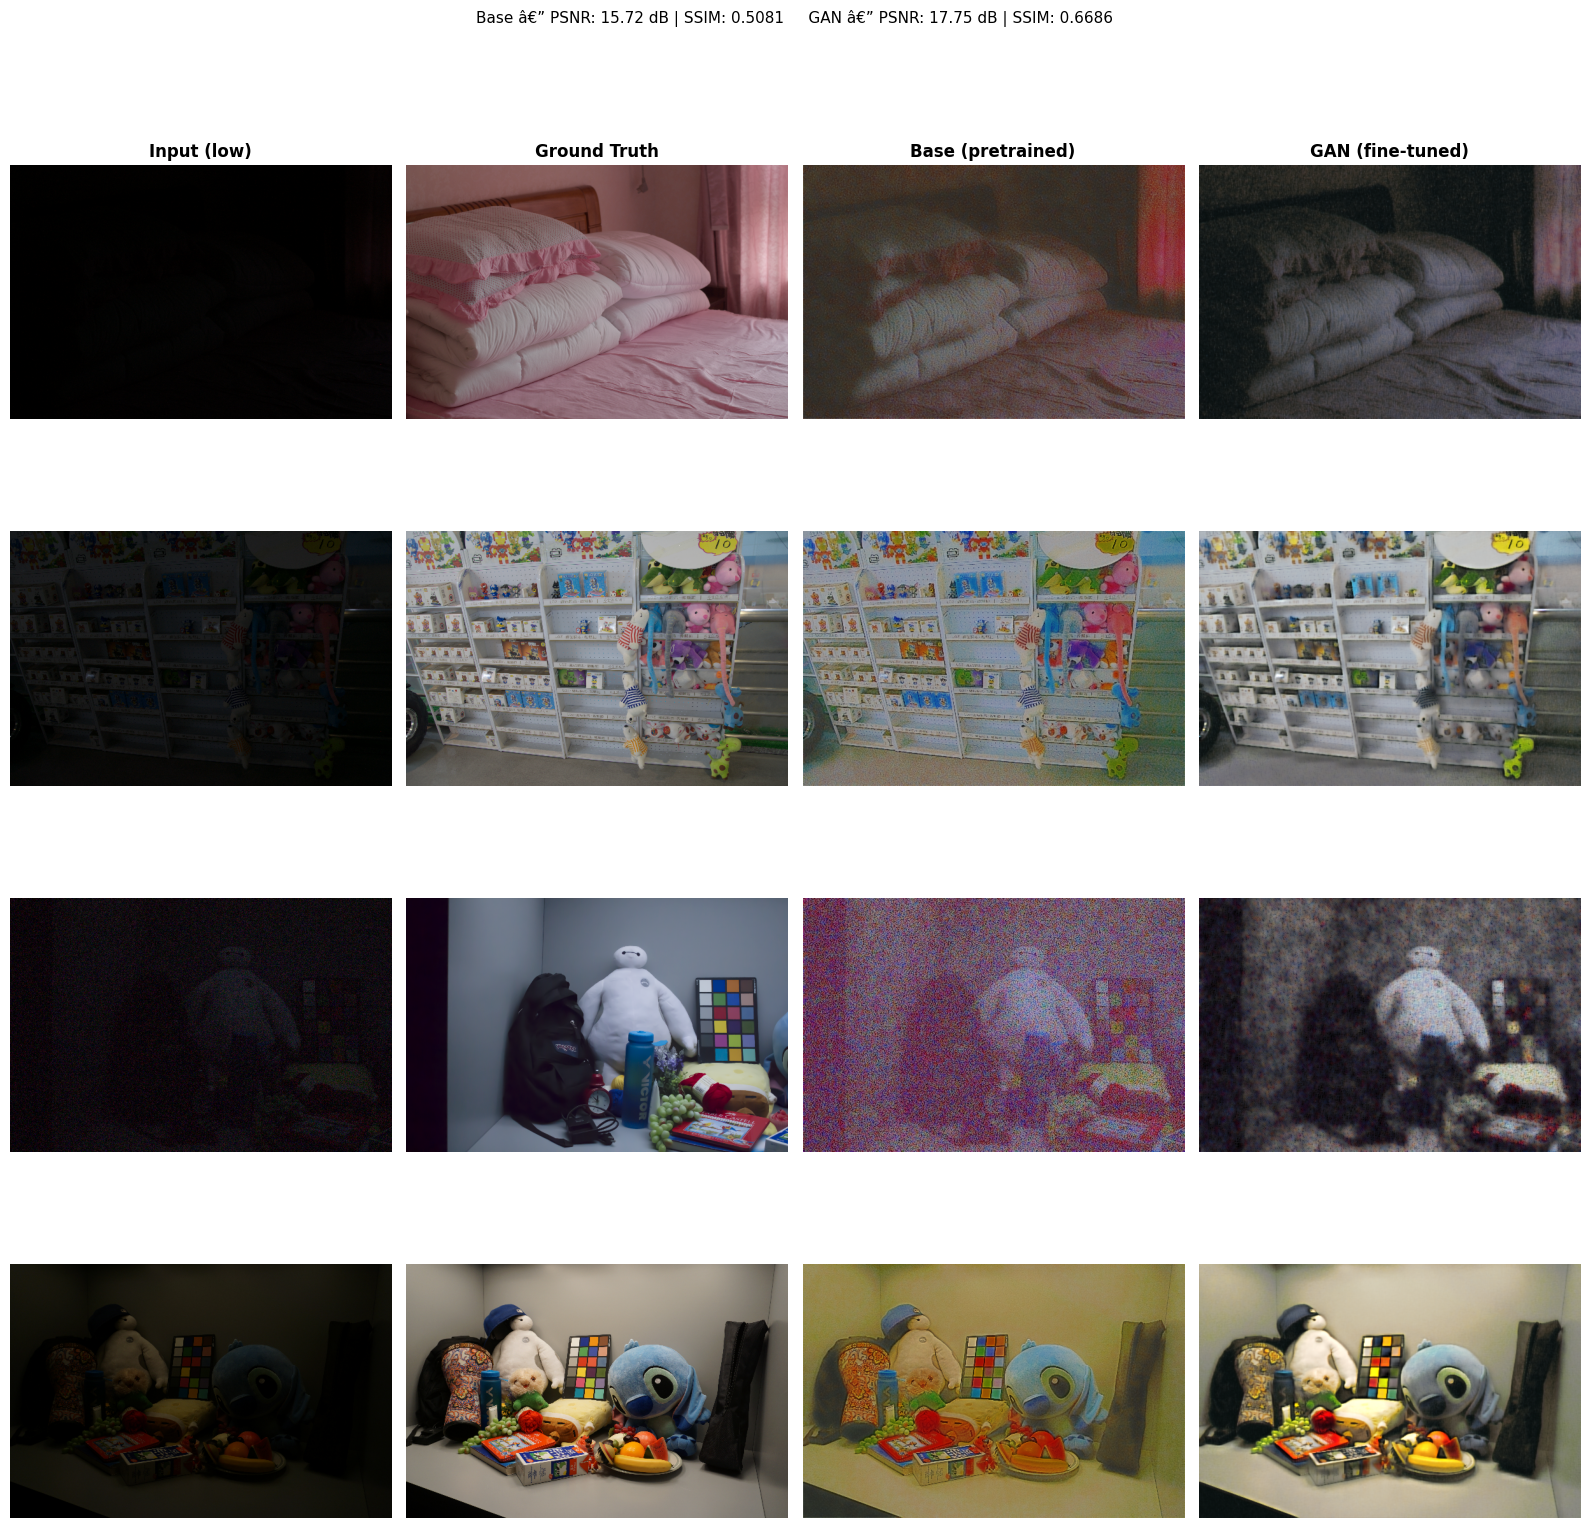

Guardado: comparacion_base_vs_gan.png


In [17]:
# Grid visual: 4 imágenes - input | GT | Base | GAN
n_samples = 4
sample_loader = DataLoader(val_data, batch_size=n_samples, shuffle=False)
low_samples, gt_samples = next(iter(sample_loader))
low_s = low_samples.to(device)
gt_s  = gt_samples.to(device)

with torch.no_grad():
    # Base
    R_b, I_b    = decom_base(low_s)
    Id_b        = relight_base(I_b, R_b)
    h, w        = Id_b.shape[2], Id_b.shape[3]
    enh_base    = torch.clamp(R_b[:, :, :h, :w] * Id_b, 0.0, 1.0)

    # GAN
    R_g, I_g    = decom_gan(low_s)
    Id_g        = relight_gan(I_g, R_g)
    h2, w2      = Id_g.shape[2], Id_g.shape[3]
    enh_gan     = torch.clamp(R_g[:, :, :h2, :w2] * Id_g, 0.0, 1.0)

def to_np(t):
    return t.cpu().numpy().transpose(1, 2, 0).clip(0, 1)

fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
col_titles = ['Input (low)', 'Ground Truth', 'Base (pretrained)', 'GAN (fine-tuned)']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for i in range(n_samples):
    axes[i, 0].imshow(to_np(low_s[i]))
    axes[i, 1].imshow(to_np(gt_s[i, :, :h, :w]))
    axes[i, 2].imshow(to_np(enh_base[i]))
    axes[i, 3].imshow(to_np(enh_gan[i]))
    for ax in axes[i]:
        ax.axis('off')

plt.suptitle(
    f'Base - PSNR: {psnr_base:.2f} dB | SSIM: {ssim_base:.4f}     '
    f'GAN - PSNR: {psnr_gan:.2f} dB | SSIM: {ssim_gan:.4f}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('comparacion_base_vs_gan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: comparacion_base_vs_gan.png')